In [42]:
import os
import json
import yaml
import random
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from huggingface_hub import login
from datasets import load_dataset, Dataset
from scipy.spatial.distance import jensenshannon
import pingouin as pg
from scipy.stats import pearsonr, pointbiserialr
from huggingface_hub import login

In [43]:
def write_to_json(file, file_path):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    with open(file_path, 'w') as f:
        json.dump(file, f, indent=2)


def read_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)

def get_hf_dataset(dataset_path, name= "analysis", split="train"):
    dataset = load_dataset(dataset_path, name=name)
    dataset = dataset[split].to_pandas()
    return dataset


In [44]:
RESPONSE_DATASET_PATH = "thoughtworks/gemma_psychometrics_personas_responses"

PERSONA_SJT_RESPONSE_DATASET_CONFIG = "analysis_sjt"
BASE_SJT_RESPONSE_DATASET_CONFIG = "base_sjt"

PERSONA_HEXACO_RESPONSE_DATASET_CONFIG = "analysis_hexaco"
BASE_HEXACO_RESPONSE_DATASET_CONFIG = "base_hexaco"


PERSONA_DATASET_PATH = "thoughtworks/psychometric_personas"
PERSONA_DATASET_CONFIG = "analysis"

In [4]:
personas = get_hf_dataset(PERSONA_DATASET_PATH, PERSONA_DATASET_CONFIG)

In [5]:
personas.shape

(500, 35)

In [45]:
with open('../../configs/generation_config.yaml', 'r') as file:
    generation_config = yaml.safe_load(file)
        
with open('../../psychometric_tests/hexaco_100_eval.yaml', 'r') as file:
    hexaco_eval = yaml.safe_load(file)

In [46]:
hexaco_base_responses = get_hf_dataset(RESPONSE_DATASET_PATH, BASE_HEXACO_RESPONSE_DATASET_CONFIG)
hexaco_persona_responses = get_hf_dataset(RESPONSE_DATASET_PATH, PERSONA_HEXACO_RESPONSE_DATASET_CONFIG)

In [47]:
sjt_base_responses = get_hf_dataset(RESPONSE_DATASET_PATH, BASE_SJT_RESPONSE_DATASET_CONFIG)

In [7]:
sjt_persona_responses = get_hf_dataset(RESPONSE_DATASET_PATH, PERSONA_SJT_RESPONSE_DATASET_CONFIG)

In [71]:
sjt_persona_responses.shape, sjt_base_responses.shape

((750000, 27), (1500, 27))

In [9]:
sjt_persona_responses.head()

,persona_uuid,persona_hash,iter,question_hash,answer,normalized_answer,answer_index,raw_prompt,guided_choices,model_name,...,hf_sjt_config,hf_sjt_split,template_key,use_persona_template,answer_shuffle,n_times,model,max_tokens,temperature,top_p
0,db426848-1df8-403e-8727-0ef1faa15e6b,0809aa6ab00b1929d557f62f74d9e1a42838dcb9e13c77...,0,52b7b7194c743b3277082008b675507e556b447cb7784e...,5,conscientiousness_option,"[2, 5, 1, 0, 4, 3]",SYSTEM:\nYou are a law enforcement officer wit...,"[1, 2, 3, 4, 5, 6]",google/gemma-3-4b-it,...,analysis,train,gpt,True,True,5,google/gemma-3-4b-it,1,0.3,0.9
1,db426848-1df8-403e-8727-0ef1faa15e6b,0809aa6ab00b1929d557f62f74d9e1a42838dcb9e13c77...,0,2048c297edf0fe96125c5c9761b30d8419b3ea87d422be...,4,conscientiousness_option,"[0, 2, 1, 4, 3, 5]",SYSTEM:\nYou are a law enforcement officer wit...,"[1, 2, 3, 4, 5, 6]",google/gemma-3-4b-it,...,analysis,train,gpt,True,True,5,google/gemma-3-4b-it,1,0.3,0.9
2,db426848-1df8-403e-8727-0ef1faa15e6b,0809aa6ab00b1929d557f62f74d9e1a42838dcb9e13c77...,0,b33e68848aaf6c86ba243656dedeb34d7a592feead36cb...,3,agreeableness_option,"[5, 1, 3, 0, 4, 2]",SYSTEM:\nYou are a law enforcement officer wit...,"[1, 2, 3, 4, 5, 6]",google/gemma-3-4b-it,...,analysis,train,gpt,True,True,5,google/gemma-3-4b-it,1,0.3,0.9
3,db426848-1df8-403e-8727-0ef1faa15e6b,0809aa6ab00b1929d557f62f74d9e1a42838dcb9e13c77...,0,0617ab0915cbc9bf5614f1fc7d9a16e8382494cccb7895...,5,agreeableness_option,"[2, 1, 4, 0, 3, 5]",SYSTEM:\nYou are a law enforcement officer wit...,"[1, 2, 3, 4, 5, 6]",google/gemma-3-4b-it,...,analysis,train,gpt,True,True,5,google/gemma-3-4b-it,1,0.3,0.9
4,db426848-1df8-403e-8727-0ef1faa15e6b,0809aa6ab00b1929d557f62f74d9e1a42838dcb9e13c77...,0,36b757dba392e4e053ccdd15749a4c0680d41bcc36f85f...,2,conscientiousness_option,"[5, 4, 2, 0, 3, 1]",SYSTEM:\nYou are a law enforcement officer wit...,"[1, 2, 3, 4, 5, 6]",google/gemma-3-4b-it,...,analysis,train,gpt,True,True,5,google/gemma-3-4b-it,1,0.3,0.9


In [48]:
dist = pd.crosstab([sjt_persona_responses["persona_uuid"], sjt_persona_responses["question_hash"]], sjt_persona_responses["normalized_answer"]).reset_index()

base_dist = pd.crosstab([sjt_base_responses["persona_uuid"], sjt_base_responses["question_hash"]], sjt_base_responses["normalized_answer"]).reset_index()

In [11]:
trait_stats = (
    sjt_persona_responses.groupby(["persona_uuid","iter"])["normalized_answer"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)

)

base_trait_stats = (
    sjt_base_responses.groupby(["persona_uuid","iter"])["normalized_answer"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)

)

### Consistency Findings:

- the distribution of drift across iterations is less (measured by JS divergence)
- the trait estimation across iterations is reliable and consistent (measured by ICC)

In [12]:
trait_stats.head()

normalized_answer                          agreeableness_option  \
persona_uuid                         iter                         
012c2119-a583-4b9f-aeab-0ad4f9a9d69b 0                 0.043333   
                                     1                 0.056667   
                                     2                 0.060000   
                                     3                 0.050000   
                                     4                 0.060000   

normalized_answer                          conscientiousness_option  \
persona_uuid                         iter                             
012c2119-a583-4b9f-aeab-0ad4f9a9d69b 0                     0.603333   
                                     1                     0.590000   
                                     2                     0.633333   
                                     3                     0.633333   
                                     4                     0.653333   

normalized_answer                          emotionality_option  \
persona_uuid                         iter                        
012c2119-a583-4b9f-aeab-0ad4f9a9d69b 0                0.086667   
                                     1                0.080000   
                                     2                0.056667   
                                     3                0.073333   
                                     4                0.060000   

normalized_answer                          extraversion_option  \
persona_uuid                         iter                        
012c2119-a583-4b9f-aeab-0ad4f9a9d69b 0                0.000000   
                                     1                0.003333   
                                     2                0.000000   
                                     3                0.000000   
                                     4                0.000000   

normalized_answer                          honesty_humility_option  \
persona_uuid                         iter                            
012c2119-a583-4b9f-aeab-0ad4f9a9d69b 0                    0.216667   
                                     1                    0.216667   
                                     2                    0.220000   
                                     3                    0.213333   
                                     4                    0.176667   

normalized_answer                          openness_option  
persona_uuid                         iter                   
012c2119-a583-4b9f-aeab-0ad4f9a9d69b 0            0.050000  
                                     1            0.053333  
                                     2            0.030000  
                                     3            0.030000  
                                     4            0.050000

In [70]:

def compute_js_stability(trait_dist):

    js_scores = {}

    for persona, g in trait_dist.groupby(level=0):

        dist = g.values

        pairwise = []

        for i in range(len(dist)):
            for j in range(i+1, len(dist)):
                js = jensenshannon(dist[i], dist[j])**2
                pairwise.append(js)

        js_scores[persona] = np.mean(pairwise)

    return pd.Series(js_scores, name="js_divergence")

In [71]:
persona_js_stability = compute_js_stability(trait_stats)
base_js_stability = compute_js_stability(base_trait_stats)

In [80]:
np.round(persona_js_stability.mean(),3).item(), np.round(base_js_stability.mean(),3).item()

(0.003, 0.003)

In [73]:
trait_dist = trait_stats.reset_index()

In [74]:
icc_results = []

for trait in trait_stats.columns:

    df_trait = trait_dist[["persona_uuid","iter",trait]].rename(
        columns={trait:"score"}
    )

    icc = pg.intraclass_corr(
        data=df_trait,
        targets="persona_uuid",
        raters="iter",
        ratings="score"
    )

    icc2 = icc[icc["Type"] == "ICC2"]["ICC"].values[0]

    icc_results.append({
        "trait": trait,
        "ICC": icc2
    })

icc_results = pd.DataFrame(icc_results)

In [75]:
icc_results

,trait,ICC
0,agreeableness_option,0.991702
1,conscientiousness_option,0.989914
2,emotionality_option,0.929927
3,extraversion_option,0.958354
4,honesty_humility_option,0.867854
5,openness_option,0.944182


In [76]:
stability_metrics_summary = {
    "JS_divergence_mean": np.round(persona_js_stability.mean(),3).item(),
    "JS_divergence_std": np.round(persona_js_stability.std(),3).item(),
    "ICC_mean": np.round(icc_results["ICC"].mean(),3).item()
}

stability_metrics_summary

{'JS_divergence_mean': 0.003, 'JS_divergence_std': 0.001, 'ICC_mean': 0.947}

### Train/Test Split comparison of most frequent option across iterations

In [49]:
option_cols = ['agreeableness_option',
       'conscientiousness_option', 'emotionality_option',
       'extraversion_option', 'honesty_humility_option', 'openness_option']


# for persona conditioned model
row_max = dist[option_cols].max(axis=1)

dist["most_frequent"] = dist[option_cols].idxmax(axis=1)
dist["tie_flag"] = dist[option_cols].eq(row_max, axis=0).sum(axis=1) > 1

dist["tied_options"] = dist[option_cols].apply(
    lambda r: r.index[r == r.max()].tolist(), axis=1
)


# for base model
base_row_max = base_dist[option_cols].max(axis=1)

base_dist["most_frequent"] = base_dist[option_cols].idxmax(axis=1)
base_dist["tie_flag"] = base_dist[option_cols].eq(base_row_max, axis=0).sum(axis=1) > 1

base_dist["tied_options"] = base_dist[option_cols].apply(
    lambda r: r.index[r == r.max()].tolist(), axis=1
)

In [14]:
dist['tie_flag'].value_counts()/dist.shape[0]

tie_flag
False    0.946627
True     0.053373
Name: count, dtype: float64

In [50]:
base_dist['tie_flag'].value_counts()/base_dist.shape[0]

tie_flag
False    0.96
True     0.04
Name: count, dtype: float64

In [51]:
dropped_dist = dist[~dist['tie_flag']]
base_dropped_dist = base_dist[~base_dist['tie_flag']]

In [17]:
### get train/test split for SJTs

total_sjt_ids = list(dist['question_hash'].drop_duplicates())

random.seed(42)
random.shuffle(total_sjt_ids)

split_idx = int(0.8 * len(total_sjt_ids))

train_sjts = total_sjt_ids[:split_idx]
test_sjts = total_sjt_ids[split_idx:]

print(f"Train SJTs: {len(train_sjts)}")
print(f"Test SJTs: {len(test_sjts)}")

Train SJTs: 240
Test SJTs: 60


In [18]:
train_dist = dropped_dist[dropped_dist['question_hash'].isin(train_sjts)]
test_dist = dropped_dist[dropped_dist['question_hash'].isin(test_sjts)]

In [19]:
train_dist.shape, test_dist.shape

((113819, 11), (28175, 11))

In [20]:
train_dist.columns

Index(['persona_uuid', 'question_hash', 'agreeableness_option',
       'conscientiousness_option', 'emotionality_option',
       'extraversion_option', 'honesty_humility_option', 'openness_option',
       'most_frequent', 'tie_flag', 'tied_options'],
      dtype='object', name='normalized_answer')

In [21]:
sjt_score = dropped_dist.groupby("persona_uuid")["most_frequent"]\
    .value_counts(normalize=True)\
    .unstack(fill_value=0).reset_index()

train_sjt_score = train_dist.groupby("persona_uuid")["most_frequent"]\
    .value_counts(normalize=True)\
    .unstack(fill_value=0).reset_index()
    
    
test_sjt_score = test_dist.groupby("persona_uuid")["most_frequent"]\
    .value_counts(normalize=True)\
    .unstack(fill_value=0).reset_index()

In [52]:
base_sjt_score = base_dropped_dist.groupby("persona_uuid")["most_frequent"]\
    .value_counts(normalize=True)\
    .unstack(fill_value=0).reset_index()

In [24]:
# sjt_score.to_csv("../../experiment_results/analysis_2026MarARR/persona500_sjt_score.csv",index=False)
# base_sjt_score.to_csv("../../experiment_results/analysis_2026MarARR/base_sjt_score.csv",index=False)

In [58]:
train_persona_id = train_sjt_score["persona_uuid"]
test_persona_id = test_sjt_score["persona_uuid"]

X_train = train_sjt_score[option_cols].values
X_test = test_sjt_score[option_cols].values

In [59]:
from scipy.spatial.distance import cdist

js_dist = cdist(X_test, X_train, metric="jensenshannon")
sim_matrix = 1 - js_dist

In [61]:
# Most Similar ID

best_idx = sim_matrix.argmax(axis=1)

most_similar_id = train_persona_id.iloc[best_idx].values

In [110]:
ranks = []
top10_flags = []
percentiles = []

N = len(train_persona_id)

for i, test_id in enumerate(test_persona_id):
    sims = sim_matrix[i]

    sorted_idx = np.argsort(-sims)  # descending

    if test_id in train_persona_id.values:
        true_idx = np.where(train_persona_id.values == test_id)[0][0]
        rank = np.where(sorted_idx == true_idx)[0][0] + 1

        percentile = 1 - (rank - 1) / N
        top10 = percentile >= 0.90

    else:
        rank = None
        percentile = None
        top10 = False

    ranks.append(rank)
    percentiles.append(percentile)
    top10_flags.append(top10)

In [111]:
similarity_result = test_sjt_score[["persona_uuid"]].copy()

similarity_result["most_similar_train_id"] = most_similar_id
similarity_result["self_rank"] = ranks
similarity_result["percentiles"] = percentiles
similarity_result["top10_percentile_flag"] = top10_flags

In [115]:
similarity_result['top10_percentile_flag'].sum()/similarity_result.shape[0]

np.float64(0.84)

In [116]:
similarity_result

most_frequent,persona_uuid,most_similar_train_id,self_rank,percentiles,top10_percentile_flag
0,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,989e1a39-f4b8-4408-a0df-a6a8d0ed2d91,32,0.938,True
1,014ba10f-8acd-457e-9037-e261803e157f,014ba10f-8acd-457e-9037-e261803e157f,1,1.000,True
2,023aed03-74e5-4d94-9cb7-e8666f1bba99,1b380788-aeae-48cb-abb3-15c02ff37436,22,0.958,True
3,04ded9e6-4f9a-46f4-a599-45a8293be256,0a7aa465-c63e-47b5-ac15-d3ee1affe14c,3,0.996,True
4,059599ce-6ed4-4daa-a731-a9749eada7f1,293b9c6b-923d-4fbd-a8ff-820fc17dd25f,66,0.870,False
...,...,...,...,...,...
495,fcb2c439-fdb7-450f-ae15-20cc3fd2c8e8,bc93ec64-1a1f-42b9-a170-090be9a0e672,68,0.866,False
496,fd63f356-df5a-45dd-a646-fc73bff4f4a8,38e06382-816c-4ee7-bedc-c6a18f626cfc,7,0.988,True
497,fd87cb8d-5b38-47c5-985d-d0923d126e08,e6976eca-de95-4286-92e8-3323adfc7739,12,0.978,True
498,fd8db6fd-b388-4331-82f5-fcc0f73acb26,511f4d02-6ad5-46a2-a051-1784286556eb,15,0.972,True


In [65]:
personas[['uuid','archetype']]

,uuid,archetype
0,db426848-1df8-403e-8727-0ef1faa15e6b,The Problem Solver / Public Servant
1,9b5d5f04-9bed-4784-86f6-032a87c1a794,The Enforcer (Crime-Fighter)
2,0eec5e8c-c292-4f78-bf4c-fa337fab358d,The Avoider (Unconfident Officer)
3,81914447-9400-48d3-bfa0-b335fcaa0f62,The Professional (Service-Oriented Officer)
4,0a885c0c-3670-4380-a115-2ed1baf04d68,The Professional (Service-Oriented Officer)
...,...,...
495,f28086b4-c944-4ed8-a635-279d58d28104,The Avoider (Lazy Officer)
496,511f4d02-6ad5-46a2-a051-1784286556eb,The Problem Solver / Public Servant
497,417cecfa-e3af-421f-85c1-fa96a2ce8c7a,The Problem Solver / Public Servant
498,15d8ba70-2a0b-4743-be4c-f97f47ca3fab,The Tough Cop (Authoritarian)


In [66]:
similarity_result = pd.merge(
pd.merge(similarity_result,personas[['uuid','archetype']], left_on="persona_uuid", right_on = "uuid").rename(columns={"archetype":"persona_archetype"}),
personas[['uuid','archetype']], left_on = "most_similar_train_id", right_on="uuid").rename(columns={"archetype":"most_similar_train_archetype"}).drop(["uuid_x","uuid_y"], axis=1)

In [67]:
sum(similarity_result['persona_archetype'] == similarity_result['most_similar_train_archetype'])

208

## Trait Shift from base to persona conditioned

### Obversations
- the reciprocator (nice cop) has a big increase in the agreeableness score and a equivalent decrease in conscientiousness score
- on an avg when the increase is in agreeableness score, the corresponding decrease is always in conscientiousness score
- when the increase in conscientiousness score, the corresponding decrease is always in the honesty humility score

In [98]:
trait_sjt_score_diff = train_sjt_score[option_cols] - base_sjt_score[option_cols].iloc[0]
trait_sjt_score_diff['persona_uuid'] = train_sjt_score['persona_uuid']

In [101]:
trait_sjt_score_diff = pd.merge(trait_sjt_score_diff,personas[['uuid','archetype']], left_on="persona_uuid", right_on = "uuid")

In [108]:
trait_sjt_score_diff.groupby("archetype")[option_cols].median()

,agreeableness_option,conscientiousness_option,emotionality_option,extraversion_option,honesty_humility_option,openness_option
archetype,,,,,,
The Avoider (Lazy Officer),-0.012006,0.196537,-0.000902,-0.034722,-0.172778,0.007298
The Avoider (Unconfident Officer),0.028818,0.052432,0.020594,-0.034722,-0.116742,0.017222
The Enforcer (Crime-Fighter),-0.020525,0.064474,-0.009424,0.000755,-0.076162,0.014028
The Problem Solver / Investigator,-0.024609,0.152708,-0.013889,-0.026064,-0.112926,0.021122
The Problem Solver / Public Servant,0.088378,-0.167693,0.004048,-0.007816,-0.051901,0.066829
The Professional (Service-Oriented Officer),0.129041,-0.139235,-0.000221,-0.012598,-0.049780,0.035885
The Reciprocator (Nice Cop),0.341895,-0.326389,0.014280,-0.012200,-0.104833,0.045472
The Tough Cop (Authoritarian),-0.024645,0.096744,-0.013889,0.000602,-0.084149,0.011589


In [106]:
trait_sjt_score_diff.describe()

,agreeableness_option,conscientiousness_option,emotionality_option,extraversion_option,honesty_humility_option,openness_option
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.083128,-0.017639,0.005886,-0.008621,-0.095885,0.033132
std,0.144313,0.210609,0.024977,0.033605,0.059615,0.035116
min,-0.041667,-0.488283,-0.013889,-0.034722,-0.243814,-0.013889
25%,-0.024573,-0.202515,-0.009674,-0.030417,-0.138530,0.011428
50%,0.015103,0.045343,-0.000958,-0.020897,-0.095933,0.023537
75%,0.156756,0.162088,0.013415,0.000520,-0.050638,0.047515
max,0.639948,0.327778,0.171825,0.198154,0.054469,0.370370


## Hexaco Comparison against SJT

### Observations
- In many human personality studies:
    - 0.25–0.35 is already considered reasonable convergent validity.
- We are getting same trait correlation scores in these ranges, but our cross-trait correlation scores are often higher than same-trait corr score

In [55]:
def calculate_hexaco_score(trait, subtrait, answers, likert_scale = generation_config['likert_scale']):
    # answer_dict = {}
    answers = [answer if answer in likert_scale else "Do not wish to answer" for answer in answers]
    answers = pd.Series(answers)
    subtrait_dict = hexaco_eval[trait][subtrait]
    indices = [idx - 1 for idx in subtrait_dict['indices']]
    trait_answers = answers[indices]
    refused_answers = trait_answers[trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    non_refused_answers = trait_answers[~trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    answer_indices = [likert_scale.index(answer) + 1 for answer in non_refused_answers]
    # print(answer_indices)
    true_answer_indices = [6-idx if reverse else idx for idx,reverse in zip(answer_indices, subtrait_dict['reverse'])]
    
    # answer_dict['answer_indices'] = answer_indices
    # answer_dict['true_answer_indices'] = true_answer_indices
    # answer_dict['n_answered_questions'] = len(true_answer_indices)
    # answer_dict['n_refused_questions'] = len(refused_answers)
    # answer_dict['trait'] = trait
    # answer_dict['subtrait'] = subtrait
    # answer_dict['subtrait_score'] = np.round(np.mean(true_answer_indices).item(),3)
    return true_answer_indices

def get_trait_scores(answer,likert_scale = generation_config['likert_scale']):
    trait_score = []
    for trait in hexaco_eval.keys():
        for subtrait in hexaco_eval[trait].keys():
            trait_true_answer_indices = []
            trait_true_answer_indices.extend(calculate_hexaco_score(trait, subtrait, answer, likert_scale))
        
        trait_score.append(np.round(np.mean(trait_true_answer_indices).item(),3).item())
    return trait_score

In [56]:
base_hexaco_str_answers = (
    hexaco_base_responses.groupby(["persona_id", "iter"])["answer"]
    .apply(list)
    .reset_index(name="answers")
)

persona_hexaco_str_answers = (
    hexaco_persona_responses.groupby(["persona_id", "iter"])["answer"]
    .apply(list)
    .reset_index(name="answers")
)

In [57]:
trait_list = ['honest-humility','emotionality','extraversion','agreeableness','conscientiousness','openness to experience','altruism']

In [30]:
persona_hexaco_str_answers

,persona_id,iter,answers
0,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,0,"[Disagree, Neutral, Agree, Neutral, Neutral, D..."
1,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,1,"[Disagree, Neutral, Agree, Neutral, Agree, Agr..."
2,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,2,"[Neutral, Neutral, Disagree, Disagree, Neutral..."
3,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,3,"[Neutral, Neutral, Disagree, Neutral, Agree, D..."
4,012c2119-a583-4b9f-aeab-0ad4f9a9d69b,4,"[Neutral, Neutral, Disagree, Disagree, Agree, ..."
...,...,...,...
2495,ffa278d0-86f2-4334-bf8e-e4cf6dbaff7a,0,"[Agree, Agree, Neutral, Agree, Agree, Agree, N..."
2496,ffa278d0-86f2-4334-bf8e-e4cf6dbaff7a,1,"[Agree, Agree, Agree, Agree, Agree, Agree, Neu..."
2497,ffa278d0-86f2-4334-bf8e-e4cf6dbaff7a,2,"[Neutral, Neutral, Agree, Neutral, Agree, Agre..."
2498,ffa278d0-86f2-4334-bf8e-e4cf6dbaff7a,3,"[Agree, Neutral, Neutral, Agree, Agree, Strong..."


In [58]:
base_hexaco_trait_df = pd.DataFrame(base_hexaco_str_answers.apply(lambda x: get_trait_scores(x['answers']),axis = 1).to_list(), index = base_hexaco_str_answers.index, columns = trait_list)
base_hexaco_trait_df['persona_id'] = base_hexaco_str_answers['persona_id']
base_hexaco_trait_df['iter'] = base_hexaco_str_answers['iter']

In [32]:
persona_hexaco_trait_df = pd.DataFrame(persona_hexaco_str_answers.apply(lambda x: get_trait_scores(x['answers']),axis = 1).to_list(), index = persona_hexaco_str_answers.index, columns = trait_list)
persona_hexaco_trait_df['persona_id'] = persona_hexaco_str_answers['persona_id']
persona_hexaco_trait_df['iter'] = persona_hexaco_str_answers['iter']

/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: 

In [85]:
persona_hexaco_trait_df.index = persona_hexaco_trait_df['persona_id']
persona_hexaco_trait_df.drop("persona_id",axis = 1,inplace=True)

In [87]:
persona_js_stability = compute_js_stability(persona_hexaco_trait_df)
base_js_stability = compute_js_stability(base_hexaco_trait_df)

/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [97]:
persona_hexaco_dist = persona_hexaco_trait_df.reset_index()

In [96]:
persona_hexaco_trait_df.fillna(0, inplace = True)

In [110]:
icc_results = []

option_cols = ['honest-humility', 'emotionality', 'extraversion', 'agreeableness',
       'conscientiousness', 'openness to experience']

for trait in option_cols:
    print(trait)
    df_trait = persona_hexaco_dist[["persona_id","iter",trait]].rename(
        columns={trait:"score"}
    )

    icc = pg.intraclass_corr(
        data=df_trait,
        targets="persona_id",
        raters="iter",
        ratings="score",
    )

    icc2 = icc[icc["Type"] == "ICC2"]["ICC"].values[0]

    icc_results.append({
        "trait": trait,
        "ICC": icc2
    })

icc_results = pd.DataFrame(icc_results)

honest-humility
emotionality
extraversion
agreeableness
conscientiousness
openness to experience


In [111]:
icc_results

,trait,ICC
0,honest-humility,0.293357
1,emotionality,0.599375
2,extraversion,0.153647
3,agreeableness,0.200470
4,conscientiousness,0.140867
5,openness to experience,0.156030


In [60]:
persona_hexaco_dist = pd.crosstab([hexaco_persona_responses["persona_id"], hexaco_persona_responses["question_idx"]], hexaco_persona_responses["answer"]).reset_index()

base_hexaco_dist = pd.crosstab([hexaco_base_responses["persona_id"], hexaco_base_responses["question_idx"]], hexaco_base_responses["answer"]).reset_index()

In [61]:
base_hexaco_dist.columns

Index(['persona_id', 'question_idx', 'Agree', 'Disagree', 'Neutral',
       'Strongly agree', 'Strongly disagree'],
      dtype='object', name='answer')

In [62]:
hexaco_option_cols = ['Agree', 'Disagree', 'Neutral',
       'Strongly agree', 'Strongly disagree']


# for persona conditioned model
hexaco_persona_row_max = persona_hexaco_dist[hexaco_option_cols].max(axis=1)

persona_hexaco_dist["most_frequent"] = persona_hexaco_dist[hexaco_option_cols].idxmax(axis=1)
persona_hexaco_dist["tie_flag"] = persona_hexaco_dist[hexaco_option_cols].eq(hexaco_persona_row_max, axis=0).sum(axis=1) > 1

persona_hexaco_dist["tied_options"] = persona_hexaco_dist[hexaco_option_cols].apply(
    lambda r: r.index[r == r.max()].tolist(), axis=1
)


# for base model
base_hexaco_row_max = base_hexaco_dist[hexaco_option_cols].max(axis=1)

base_hexaco_dist["most_frequent"] = base_hexaco_dist[hexaco_option_cols].idxmax(axis=1)
base_hexaco_dist["tie_flag"] = base_hexaco_dist[hexaco_option_cols].eq(base_hexaco_row_max, axis=0).sum(axis=1) > 1

base_hexaco_dist["tied_options"] = base_hexaco_dist[hexaco_option_cols].apply(
    lambda r: r.index[r == r.max()].tolist(), axis=1
)

In [63]:
base_hexaco_grouped_str_answers = (
    base_hexaco_dist.groupby(["persona_id"])["most_frequent"]
    .apply(list)
    .reset_index(name="answers")
)


persona_hexaco_grouped_str_answers = (
    persona_hexaco_dist.groupby(["persona_id"])["most_frequent"]
    .apply(list)
    .reset_index(name="answers")
)

In [64]:
base_hexaco_grouped_trait_df = pd.DataFrame(base_hexaco_grouped_str_answers.apply(lambda x: get_trait_scores(x['answers']),axis = 1).to_list(), index = base_hexaco_grouped_str_answers.index, columns = trait_list)
base_hexaco_grouped_trait_df['persona_id'] = base_hexaco_grouped_str_answers['persona_id']

In [39]:
persona_hexaco_grouped_trait_df = pd.DataFrame(persona_hexaco_grouped_str_answers.apply(lambda x: get_trait_scores(x['answers']),axis = 1).to_list(), index = persona_hexaco_grouped_str_answers.index, columns = trait_list)
persona_hexaco_grouped_trait_df['persona_id'] = persona_hexaco_grouped_str_answers['persona_id']

/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [41]:
# persona_hexaco_grouped_trait_df.to_csv("../../experiment_results/analysis_2026MarARR/persona500_hexaco_scores.csv",index = False)
# base_hexaco_grouped_trait_df.to_csv("../../experiment_results/analysis_2026MarARR/base_hexaco_scores.csv",index = False)

In [199]:
sjt_col_order = ['agreeableness_option', 'conscientiousness_option',
       'emotionality_option', 'extraversion_option', 'honesty_humility_option',
       'openness_option']
hexaco_col_order = ['agreeableness','conscientiousness','emotionality','extraversion','honest-humility','openness to experience']

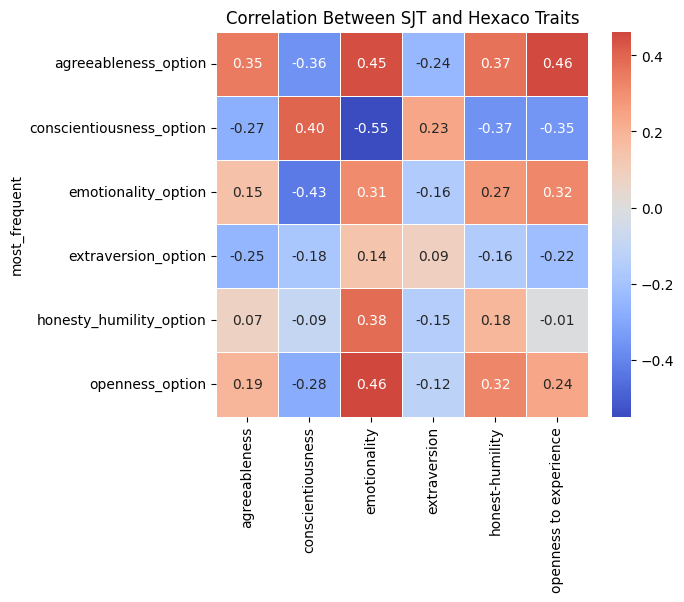

In [212]:
corr_matrix = pd.DataFrame(
    {col: train_sjt_score[sjt_col_order].corrwith(persona_hexaco_grouped_trait_df[col]) for col in hexaco_col_order}
)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,      # show numbers
    fmt=".2f",       # format to 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Between SJT and Hexaco Traits")
plt.show()